##**Black Friday Customer Purchase Analysis**

###**✦ Project Overview:**

* This project analyzes customer purchasing behavior during a major retail sales event using transaction data. The objective is to identify spending patterns across different customer segments by examining demographic attributes such as age, gender, occupation, city category, and marital status.

* The analysis combines Exploratory Data Analysis (EDA) with statistical techniques, including the Central Limit Theorem (CLT) and Confidence Interval Analysis, to understand customer spending behavior and generate meaningful business insights. The findings can help retail businesses make informed decisions related to customer segmentation, targeted marketing, promotional campaigns, and inventory planning.

### **✦ Business Objective:**

* The primary objective of this project is to analyze customer purchase behavior and identify the factors that influence spending during a large-scale retail sales event. Specifically, this project aims to:

* Understand customer demographics and purchasing patterns.
Analyze how spending varies across different customer segments.
Apply statistical techniques such as the Central Limit Theorem (CLT) and Confidence Intervals to estimate population characteristics from sample data.
Generate data-driven business insights that support marketing strategies, customer targeting, and inventory planning.

###**✦ Dataset Description:**

* The dataset contains customer demographic information and purchase transaction details collected during a major retail sales event. Each record represents an individual customer's purchase along with demographic attributes such as gender, age group, occupation, city category, years of residence in the current city, marital status, and purchased product categories.

* The dataset is used to analyze customer purchasing behavior, identify spending patterns across different customer segments, and perform statistical analysis to support data-driven business decision-making.

##**✦ Project Workflow:**

Dataset

 ↓
    
Data Understanding

  ↓

Data Cleaning

  ↓

Exploratory Data Analysis (EDA)

  ↓

Statistical Analysis

  ↓

Central Limit Theorem (CLT)

  ↓

Confidence Interval Analysis

  ↓

Key Business Insights

  ↓

Business Recommendations

## Dataset Understanding

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Basic Metrics

In [108]:
!gdown https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv?1641285094
df=pd.read_csv("walmart_data.csv?1641285094")
df.head()

Downloading...
From: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv?1641285094
To: /content/walmart_data.csv?1641285094
100% 23.0M/23.0M [00:00<00:00, 166MB/s]


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


### Dataset Shape

In [109]:
df.shape

(550068, 10)

* **It is observed that the dataset contains 550,068 rows and 10 columns, indicating a large and reliable dataset suitable for analyzing customer purchasing behaviour during a major Black Friday retail sales event.**

### Data Types

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


* **It is observed that we have User_ID, Occupation,Marital_Status, Product_Category,Purchase - as Integer data types and Product_ID,Gender, Age ,City_Category and Stay_In_Current_City_Years - as Object data types in the given business data.**
* **The Purchase variable is a continuous numerical variable representing the amount spent by customers.**
* **Categorical variables such as Gender, Age, and City_Category indicate that customer segmentation analysis is feasible.**

### Unique Values

In [111]:
df.nunique()

,0
User_ID,5891
Product_ID,3631
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category,20
Purchase,18105



####**Based on the number of unique values present in each of the columns of the data and the type of values they contain we can make the data type changes as follows:**
* Variables such as **Gender, Age, Occupation ,Product_Category, City_Category,Marital_Status and Stay_In_Current_City_Years** are categorical in nature and must be converted into category data type, for memory efficiency and to improve processing speed.
* The presence of multiple unique values across variables such as Age, Occupation, and Product_Category indicates diverse customer segments and product choices.
* Binary variables like Gender and Marital_Status simplify comparative analysis between groups.

### Data Preparation

In [112]:
data_copy=df.copy()
df=df.drop(columns=['User_ID','Product_ID'])


* **The columns User_ID and Product_ID were removed as they act as unique identifiers and do not contribute meaningful information for analyzing customer purchasing behavior.**

* **Removing these columns ensures a cleaner and more relevant dataset for analysis**

### Data Type Conversion

In [113]:
cat_cols = ['Gender', 'Age', 'City_Category',
            'Stay_In_Current_City_Years', 'Marital_Status', 'Occupation','Product_Category']

for col in cat_cols:
    df[col] = df[col].astype('category')

• **Several variables such as Gender, Age, City_Category, Stay_In_Current_City_Years, Marital_Status, and Occupation were converted to categorical data types.**

• **Although some of these variables are numerically encoded (e.g., Occupation, Marital_Status), they represent discrete categories rather than continuous numerical values.**

• **Converting them to categorical ensures more meaningful analysis, especially during grouping, aggregation, and visualization by avoiding misleading numerical interpretations.**

• **This also improves memory efficiency and prevents misleading statistical summaries.**

### Statistical Summary

In [114]:
df.describe()

,Purchase
count,550068.000000
mean,9263.968713
std,5023.065394
min,12.000000
25%,5823.000000
50%,8047.000000
75%,12054.000000
max,23961.000000


* **The average purchase amount (~₹9,264) indicates a moderate-to-high spending level during Black Friday.**

* **The large standard deviation (~₹5,023) suggests high variability, indicating the presence of both budget and premium shoppers.**

* **The wide range (₹12 to ~₹23,961) highlights diverse purchasing power among customers.**

* **The right-skewed distribution(Mean>Median) indicates that a smaller group of high spenders contributes significantly to overall sales, which could be a key focus area for targeted marketing strategies.**

### Non-Graphical Analysis

###**1.2.1.Null Values Check:**

In [115]:
df.isnull().sum()

,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


 **• The dataset was checked for missing values using the isnull() function. It was observed that there are no significant missing values in the dataset.Also from "df.info", it was evident that there were no null values.**

###**1.2.2. Value counts:**

In [116]:
df['Gender'].value_counts()

,count
Gender,
M,414259
F,135809


In [117]:
df['Age'].value_counts()

,count
Age,
26-35,219587
36-45,110013
18-25,99660
46-50,45701
51-55,38501
55+,21504
0-17,15102


In [118]:
df['Occupation'].value_counts().head(6)

,count
Occupation,
4,72308
0,69638
7,59133
1,47426
17,40043
20,33562


In [119]:
df['City_Category'].value_counts()

,count
City_Category,
B,231173
C,171175
A,147720


In [120]:
df['Stay_In_Current_City_Years'].value_counts()

,count
Stay_In_Current_City_Years,
1,193821
2,101838
3,95285
4+,84726
0,74398


In [121]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
0,324731
1,225337


In [122]:
df["Product_Category"].value_counts().head(5)

,count
Product_Category,
5,150933
1,140378
8,113925
11,24287
2,23864


####**Value counts-Insights:**

🔹**Value counts and unique values are used to understand the distribution of key categorical variables.**
🔹 **Gender:** Male customers contribute a significantly higher number of transactions, indicating stronger participation during the sale.  
🔹 **Age:** The 26–35 age group has the highest number of transactions, highlighting them as the most active customer segment.  
🔹 **City_Category:** Category B and C cities contribute a higher number of transactions, indicating stronger participation from these city segments.  
🔹 **Marital_Status:** Unmarried customers contribute more transactions, suggesting higher shopping activity among this group.  
🔹 **Stay_In_Current_City_Years:** Majority of customers have shorter stay durations, indicating a relatively dynamic and mobile customer base.  
🔹 **Occupation:** Customers are distributed across multiple occupation categories, indicating a diverse customer base without reliance on a single profession.  
🔹 **Product category:** • Certain product categories (such as 5, 1, and 8) show significantly higher transaction counts, making them key contributors to overall sales.     
• This suggests that these categories are key revenue drivers and should be prioritized in inventory planning and promotions.  
🔹 **Overall,the customer base is diverse, with certain segments (such as specific age groups and product categories) contributing more to transactions, indicating uneven participation across customer groups.**

### Exploratory Data Analysis (EDA)

###**1.3.1. Exploratory Data Analysis (Univariate):**

###**(A) Univariate-Numerical variable (Purchase distribution):**

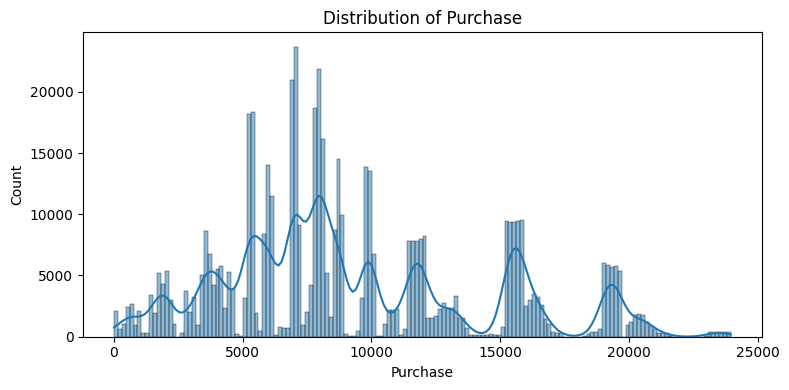

In [123]:
plt.figure(figsize=(8,4))
sns.histplot(df['Purchase'], kde=True)
plt.title('Distribution of Purchase')
plt.tight_layout()
plt.show()

####**Univariate-Numerical variable (Purchase distribution)-Insights:**  
* The purchase distribution is right-skewed, indicating that most transactions are of lower value, while a few high-value purchases contribute significantly to total revenue.

### **(B) Univariate-Categorical Variables:**

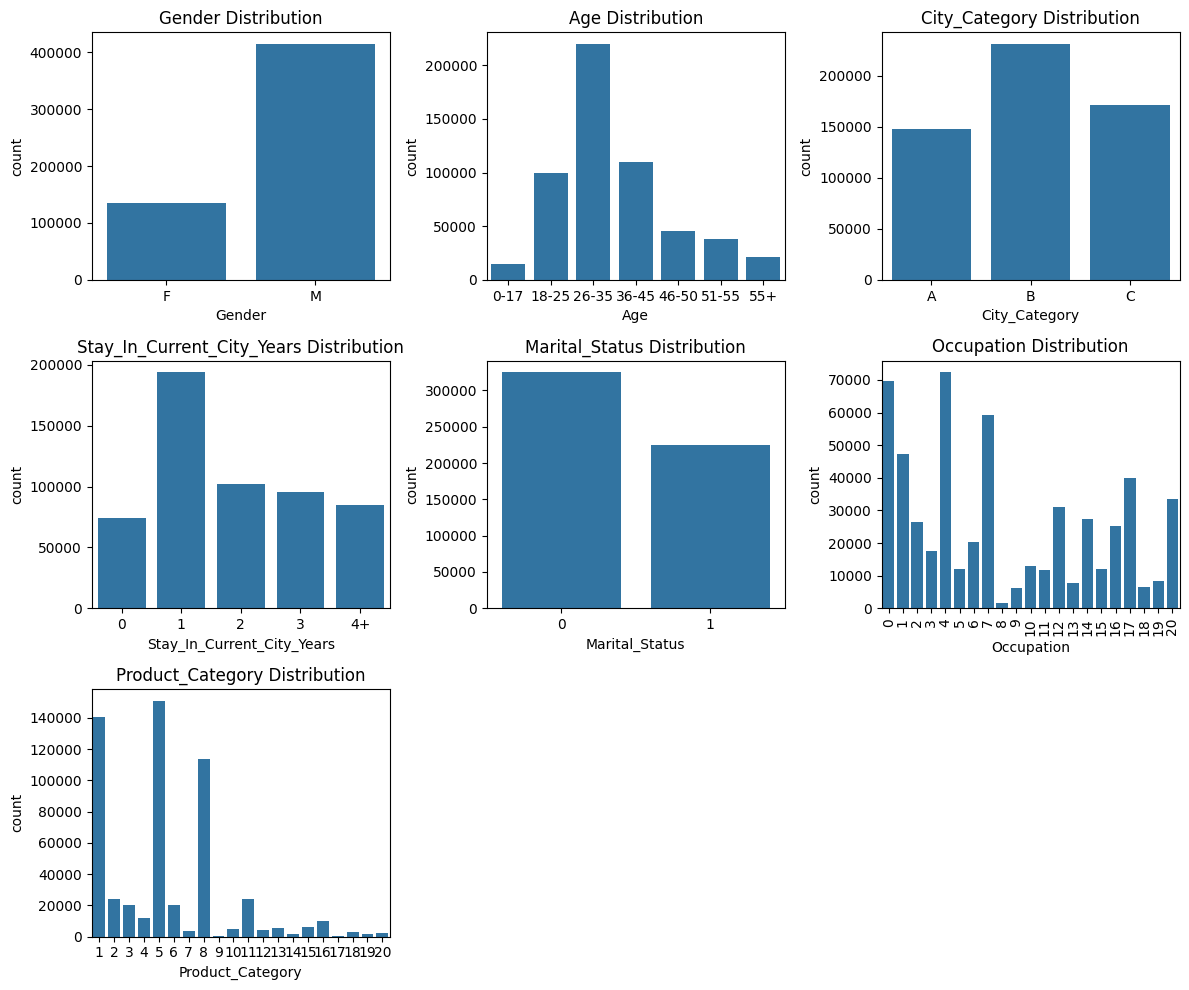

In [124]:
categorical_cols = ['Gender', 'Age', 'City_Category',
                    'Stay_In_Current_City_Years',
                    'Marital_Status', 'Occupation','Product_Category']

plt.figure(figsize=(12,10))

for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(x=col, data=df)
    plt.title(f'{col} Distribution')

    if col == 'Occupation':
        plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

####**Univariate-Categorical variables-Visual analysis-Insights:**  
* **Gender**:The dataset shows a higher proportion of male customers.
* **Age**:Most customers belong to the 26-35 age group.
* **City Category**:City Category B has the highest representation.
* **Stay_In_Current_City_Years**:Customers are largely stable in their current city for 1 year.
* **Marital_Status**:The dataset shows a slightly higher proportion of unmarried customers compared to married customers, with a diverse range of occupations.
* **Occupation**:Customers are distributed across multiple occupation categories, with some occupations having higher counts, indicating variation in professional backgrounds rather than a single dominant segment.  
* **Product_Category**: The distribution is highly uneven, with categories 5, 1, and 8 dominating. This indicates that a few product categories contribute significantly to transactions, while others have relatively low demand.  

**Overall, the customer base is diverse across demographics and occupations. However, certain segments (such as the 26–35 age group and specific product categories) contribute disproportionately to transactions, indicating concentrated purchasing behavior.**

###**1.3.2. Exploratory Data Analysis (Bivariate):**

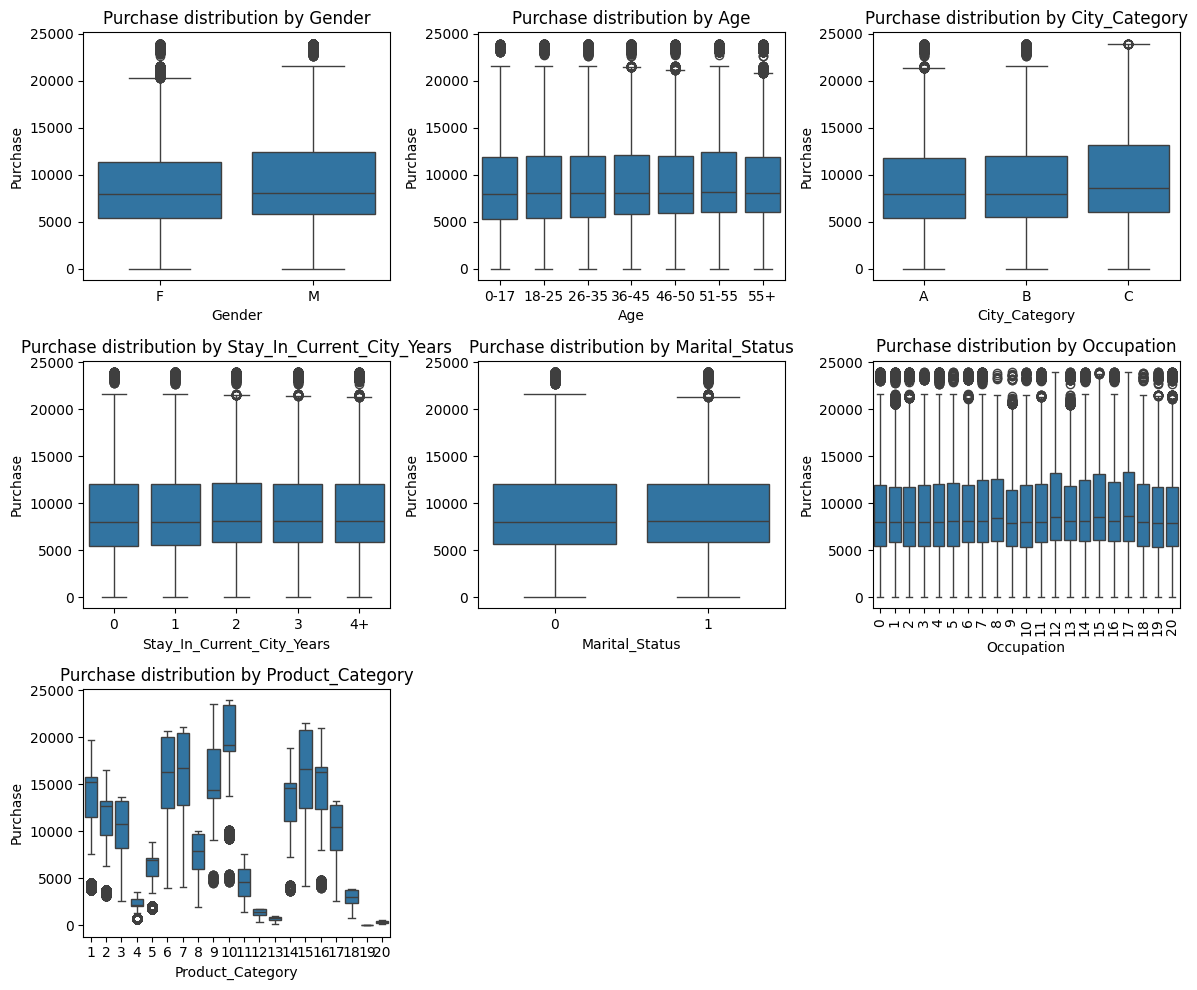

In [125]:
categorical_cols = ['Gender', 'Age', 'City_Category',
                    'Stay_In_Current_City_Years',
                    'Marital_Status', 'Occupation','Product_Category']
# Proper order for Age
age_order = ['0-17', '18-25', '26-35', '36-45',
             '46-50', '51-55', '55+']
plt.figure(figsize=(12,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    if col == 'Age':
        sns.boxplot(x=col, y='Purchase', data=df, order=age_order)
    else:
        sns.boxplot(x=col, y='Purchase', data=df)
    plt.title(f'Purchase distribution by {col}')
    if col == 'Occupation':
        plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

####**Bivariate Visual analysis-Insights:**  


**1. Overall Similar Distribution:**   
 • The purchase distribution appears broadly **similar across demographic categories such as gender, age, marital status, and city type**.  
• However, **noticeable differences are observed across product categories**,indicating variation in spending based on product type.  

**2. Median & IQR Overlap:**   
 • The **median purchase values and interquartile ranges overlap significantly across demographic categories**, indicating that no single demographic variable strongly differentiates purchasing behavior.   
• In contrast, **product categories show relatively more variation in median purchase values**.  

**3. Slight Variations:**  
• **Slight variations are observed across city categories and occupations**, where certain groups show marginally higher median purchases, **but the differences are not substantial**.   
• However,**across product categories, some segments exhibit clearly higher or lower spending levels**.   

**4. Outliers:**  
• **Male customers exhibit a slightly higher median purchase compared to female customers**, indicating marginally higher spending.       
• Additionally, **multiple low-value outliers are observed across several product categories**, suggesting the presence of low-cost products or add-ons,while most transactions remain within a moderate price range.

**5. Final Conclusion:**  
• A **few high-value outliers are observed**,indicating occasional high-spending transactions,though they are less prominent.  
• The **presence of multiple low-value outliers across product categories** suggests the availability of low-cost or add-on products within certain categories.  
• Overall, **purchasing behavior remains relatively consistent across demographic segments**, with no strong segmentation effect observed.  
• However, **product category plays a relatively more important role in influencing purchase amount compared to demographic variables**.

###**1.3.3. Correlation Analysis:Heatmaps,Pairplots**

###**1.3.3. Exploratory Data Analysis (Multivariate):**

In [126]:
df_corr = df.copy()
# Convert categorical variables to numeric
df_corr['Gender'].replace({'F':0, 'M':1}, inplace=True)
df_corr['Age'].replace({
    '0-17':0, '18-25':1, '26-35':2,
    '36-45':3, '46-50':4, '51-55':5, '55+':6
}, inplace=True)
df_corr['Marital_Status'] = df_corr['Marital_Status'].astype(int)
df_corr['Occupation'] = df_corr['Occupation'].astype(int)
df_corr_subset = df_corr[['Purchase', 'Gender', 'Age',
                         'Occupation', 'Marital_Status']]
corr_matrix = df_corr_subset.corr()
corr_matrix

,Purchase,Gender,Age,Occupation,Marital_Status
Purchase,1.000000,0.060346,0.015839,0.020833,-0.000463
Gender,0.060346,1.000000,-0.004262,0.117291,-0.011603
Age,0.015839,-0.004262,1.000000,0.091463,0.311738
Occupation,0.020833,0.117291,0.091463,1.000000,0.024280
Marital_Status,-0.000463,-0.011603,0.311738,0.024280,1.000000


###**B. Heat Map:**

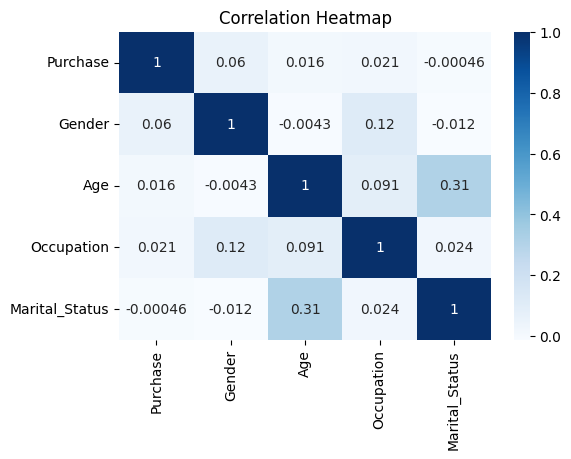

In [127]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

####**Correlation and Heatmap Insights:**
• The correlation analysis indicates that all variables have very weak relationships with purchase amount (correlation values close to zero), suggesting that no single demographic factor strongly influences customer spending.  
• Gender, age, occupation, and marital status show negligible correlation with purchase, reinforcing the observation from bivariate analysis that purchasing behavior is fairly uniform across segments.  
• A moderate positive correlation (~0.31) is observed between age and marital status, indicating that older customers are more likely to be married.  
• Overall, the lack of strong correlations suggests that purchase behavior is influenced by factors beyond the available demographic variables, such as product preferences or external factors.    
• Product_Category was not included in the correlation analysis as it represents nominal categorical data, where numeric encoding does not imply any meaningful order. Hence, correlation may not provide reliable insights for this variable.  

###**C. Pair plot:**

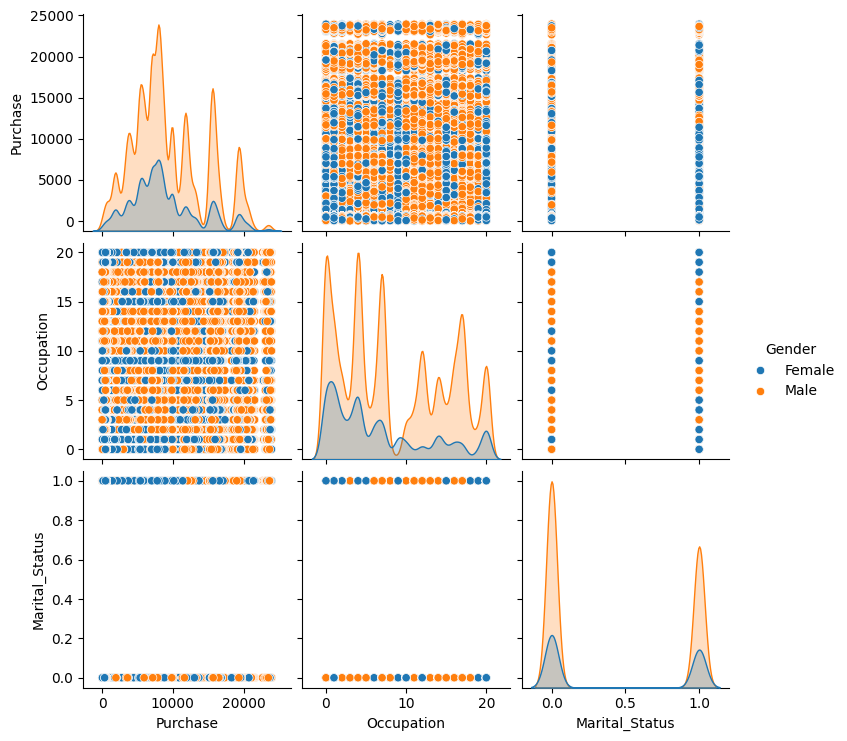

In [128]:
df_pair = df_corr_subset.copy()
df_pair['Gender'] = df_pair['Gender'].replace({0: 'Female', 1: 'Male'})
sns.pairplot(df_pair, hue='Gender')
plt.show()

####**Pair plot Insights:**     

• The pairplot shows scattered relationships between variables, indicating the absence of strong linear patterns among the features.  
• There is significant overlap between male and female data points across all variables, suggesting that gender does not significantly influence purchasing behavior.  
• No clear clustering or separation is observed among variables, reinforcing the weak correlations identified in the heatmap.  
• Due to the categorical nature of most variables (encoded numerically), the pairplot provides limited additional insights and primarily supports the findings from the correlation analysis.  
• The analysis suggests that demographic factors alone are not strong predictors of purchase behavior, indicating that business strategies should focus more on product categories, pricing, and customer experience rather than customer demographics.

In [129]:
df.groupby("Gender")["Purchase"].mean()

,Purchase
Gender,
F,8734.565765
M,9437.526040


####**Additional Statistical Insights:**
• While a few male customers appear to make higher-value purchases (as seen from points at the upper range), there is substantial overlap in the overall distribution of purchase amounts between genders. This suggests that although high-value transactions may be slightly more frequent among males, the overall spending behavior remains similar across genders.

• To further validate the visual findings, the average purchase amount was compared across genders.The average purchase amount for male and female customers is comparable, confirming that gender does not significantly influence overall spending, despite the presence of some high-value transactions among male customers.

###**2. Missing Value & Outlier Detection:**


 ### **A. Missing Value Analysis:**  

In [130]:
data_copy.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


####**Missing value analysis-Insights:**

* The dataset does not contain any missing values across all variables, indicating that no imputation or data cleaning is required for handling null entries.

###**B. Statistical Summary & Skewness:**  

In [131]:
df.describe()

,Purchase
count,550068.000000
mean,9263.968713
std,5023.065394
min,12.000000
25%,5823.000000
50%,8047.000000
75%,12054.000000
max,23961.000000


####**Statistical Summary & Skewness-Insights:**  

* From the statistical summary of the Purchase variable, the mean is slightly higher than the median, indicating a right-skewed distribution.
* This suggests that while most transactions fall within a moderate range, a few high-value purchases are pulling the average upward.

###**C. Outlier detection using Box plot:**

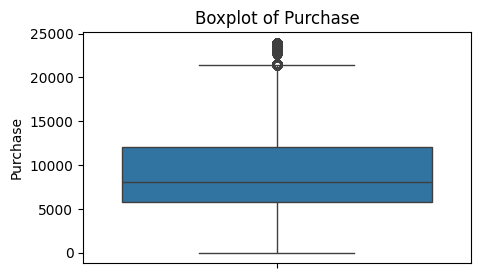

In [132]:

plt.figure(figsize=(5,3))
sns.boxplot(y=df['Purchase'])
plt.title('Boxplot of Purchase')
plt.show()

####**Outlier Detection using Boxplot-Insights:**


• A boxplot was used to visually inspect the presence of outliers in the Purchase variable.  
• The plot shows several data points beyond the upper whisker, indicating the presence of high-value outliers.  
• These outliers are likely to represent genuine high-value transactions rather than data entry errors.  
• The presence of these outliers is consistent with the right-skewed distribution observed in the statistical summary, where a few large purchases influence the overall average.  

### **3. Business Insights-Based on Non-Graphical and Visual Analysis:**

###**3.1. Comments on Range of Attributes:**

• The purchase amount spans a wide range, indicating significant variability in customer spending behavior, from low-value to high-value transactions.  
• Age groups are well distributed, covering a broad spectrum of customers, which enables analysis across different life stages.  
• Occupation and product categories exhibit multiple distinct values, reflecting diverse customer preferences and purchasing patterns.  
• Overall, the dataset captures a wide variety of customer segments, making it suitable for comprehensive behavioral analysis.  


###**3.2. Comments on distribution of Variables & Relationship between them:**
• The purchase amount distribution is right-skewed, indicating that while most transactions are of moderate value, a small number of high-value purchases significantly influence the overall average.  
• The gender distribution shows higher participation from male customers; however, spending behavior remains comparable across genders.  
• The age distribution is concentrated in the 26–35 group, but purchase behavior is relatively consistent across different age groups.  
• No strong relationship is observed between purchase amount and demographic variables such as age, gender, or marital status, suggesting that these factors do not significantly drive spending.
• Purchase amount shows noticeable variation across different product categories, indicating that product type has a stronger influence on spending behavior compared to demographic factors.  
• Correlation analysis further confirms that most variables have weak linear relationships with purchase amount, reinforcing the lack of strong predictors.  
• The presence of high-value purchases (outliers) suggests opportunities for targeted marketing strategies aimed at premium or high-spending customers.


### **3.3. Comments for Each Univariate & Bivariate Plot:**

• Univariate analysis shows that most purchase amounts are concentrated in the lower to mid range, with a few extreme values indicating high-value transactions.  
• Gender-wise distribution indicates that male customers are higher in number; however, average spending remains similar across genders.  
• Age-wise analysis shows that no specific age group dominates spending significantly, indicating uniform purchasing behavior.  
• Occupation and product category distributions highlight diverse customer preferences and varied purchasing patterns.  
• Bivariate analysis using boxplots shows that purchase behavior is largely consistent across different demographic segments, with overlapping distributions.  
• No significant differences in median purchase values are observed across categories, suggesting that demographic variables have limited influence on spending.  
• Although slight variations exist, they are not substantial enough to establish strong relationships between customer attributes and purchase amount.  
• While demographic factors show similar spending patterns, product categories introduce noticeable variation in purchase behavior.

###**3.4. Overall Business Insight-Based on Non-Graphical and Visual Analysis:**

* The analysis indicates that customer demographics such as gender, age, and marital status do not significantly influence purchase behavior.
* Instead, purchasing appears to be driven more by product-related factors, particularly product categories, suggesting that business strategies should focus on product offerings and customer experience rather than demographic segmentation alone.


###**4. Answering the Business Questions:**

###**4.1. Are women spending more than men?**

In [133]:
df.groupby('Gender')['Purchase'].mean()

,Purchase
Gender,
F,8734.565765
M,9437.526040


* **The average purchase amount for male customers is higher than female customers.This indicates that men tend to spend more per transaction compared to women.**
* **However, this conclusion is based only on sample averages and does not account for variability in the data. Therefore, statistical methods such as confidence intervals are required to validate whether this difference is significant.**

###**4.2. Confidence Interval Analysis:**

In [134]:
import numpy as np
# Set seed for reproducibility
np.random.seed(42)
#Separate data
male = df[df['Gender'] == 'M']['Purchase']
female = df[df['Gender'] == 'F']['Purchase']
#Function for CI
def confidence_interval(data, sample_size, n_iterations=1000, ci=95):
    means = []
    for _ in range(n_iterations):
        sample = np.random.choice(data, size=sample_size)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100-ci)/2)
    upper = np.percentile(means, 100-(100-ci)/2)
    return means,lower, upper

# Define the common sample size
sample_size = 10000

# Apply confidence interval function
male_ci = confidence_interval(male, sample_size)
female_ci = confidence_interval(female, sample_size)
male_ci[1],male_ci[2],female_ci[1],female_ci[2]

(np.float64(9337.8421125),
 np.float64(9539.8555025),
 np.float64(8642.938735),
 np.float64(8822.760400000001))

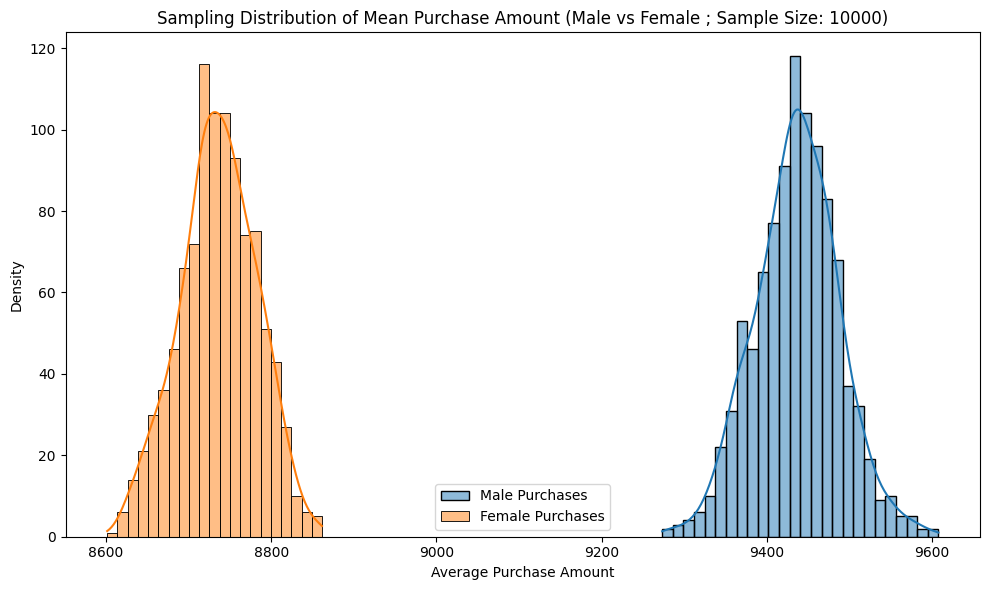

In [142]:
plt.figure(figsize=(10, 6))
sns.histplot(male_ci[0], kde=True, label='Male Purchases')
sns.histplot(female_ci[0], kde=True, label='Female Purchases')
plt.title('Sampling Distribution of Mean Purchase Amount (Male vs Female ; Sample Size: 10000)')
plt.xlabel('Average Purchase Amount')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

###**Confidence Intervals and Distribution of Mean Purchase Amounts – Insights:**

* The histograms represent the sampling distributions of the mean purchase amounts for male and female customers using a sample size of 10,000.
* Increasing the sample size results in narrower sampling distributions, providing a more precise estimate of the population means.
* The estimated 95% confidence interval for male customers is approximately (9337.84, 9539.86), while for female customers it is approximately (8642.94, 8822.76).
* The distributions are clearly separated because the larger sample size reduces sampling variability, making the difference in average purchase amounts more apparent.
* These results suggest that male customers have a higher average purchase amount than female customers in this dataset.

###**4.3.1. Are confidence intervals of average male and female spending overlapping?**

* The confidence intervals for male and female customers do not overlap.
* This indicates that the average purchase amount for male customers is consistently higher than that for female customers in this dataset.
* The larger sample size produces narrower confidence intervals, making the difference between the groups more evident.

  ###   **4.3.2. How can business leverage this conclusion to make changes or improvements?**
* Since male customers have a higher average purchase amount, Walmart can design targeted promotional campaigns, premium product bundles, and loyalty offers for higher-spending customer segments while maintaining inclusive marketing for all customers.

###**4.4. Results when the same activity is performed for Married vs Unmarried:**

In [136]:
married = df[df['Marital_Status'] == 1]['Purchase']
unmarried = df[df['Marital_Status'] == 0]['Purchase']
married_ci = confidence_interval(married, sample_size)
unmarried_ci = confidence_interval(unmarried, sample_size)
married_ci, unmarried_ci

(([np.float64(9239.2553),
   np.float64(9249.4214),
   np.float64(9237.9439),
   np.float64(9247.2873),
   np.float64(9242.6171),
   np.float64(9317.7596),
   np.float64(9330.4354),
   np.float64(9240.1364),
   np.float64(9343.7252),
   np.float64(9321.8984),
   np.float64(9356.4934),
   np.float64(9263.5861),
   np.float64(9228.5757),
   np.float64(9290.9924),
   np.float64(9226.6315),
   np.float64(9242.7532),
   np.float64(9233.6178),
   np.float64(9273.2765),
   np.float64(9229.6475),
   np.float64(9225.9722),
   np.float64(9297.34),
   np.float64(9289.0974),
   np.float64(9247.274),
   np.float64(9264.6145),
   np.float64(9180.933),
   np.float64(9268.8547),
   np.float64(9284.6951),
   np.float64(9157.5026),
   np.float64(9319.1785),
   np.float64(9238.3448),
   np.float64(9194.1021),
   np.float64(9251.7964),
   np.float64(9281.3266),
   np.float64(9245.6839),
   np.float64(9192.8504),
   np.float64(9290.5156),
   np.float64(9154.6205),
   np.float64(9270.0864),
   np.float64(93

####**Results when the same activity is performed for Married vs Unmarried-Insights:**
* Using sampling and Central Limit Theorem, we estimated confidence intervals for average spending incase of married and unmarried customers.
* The confidence interval for married customers lies between (9164.86, 9367.02), while for unmarried customers it lies between (9166.04, 9367.02).
* This represents the range in which the true population mean is expected to lie with 95% confidence.
* The average purchase amount between married and unmarried customers is very similar.
* This indicates that marital status does not significantly influence spending behavior.
* Thus, targeting based on marital status alone may not be effective.

###**4.5. Results when the same activity is performed for Age:**

In [137]:
df['Age_Group'] = df['Age']
df.groupby('Age_Group')['Purchase'].mean()

,Purchase
Age_Group,
0-17,8933.464640
18-25,9169.663606
26-35,9252.690633
36-45,9331.350695
46-50,9208.625697
51-55,9534.808031
55+,9336.280459


In [138]:
sample_size = 10000
age0 = df[df['Age'] == '0-17']['Purchase']
age1 = df[df['Age'] == '18-25']['Purchase']
age2 = df[df['Age'] == '26-35']['Purchase']
age3 = df[df['Age'] == '36-45']['Purchase']
age4 = df[df['Age'] == '46-50']['Purchase']
age5 = df[df['Age'] == '51-55']['Purchase']
age6 = df[df['Age'] == '55+']['Purchase']
age0_ci = confidence_interval(age0, sample_size)
age1_ci = confidence_interval(age1, sample_size)
age2_ci = confidence_interval(age2, sample_size)
age3_ci = confidence_interval(age3, sample_size)
age4_ci = confidence_interval(age4, sample_size)
age5_ci = confidence_interval(age5, sample_size)
age6_ci = confidence_interval(age6, sample_size)

age0_ci,age1_ci, age2_ci,age3_ci,age4_ci,age5_ci,age6_ci

(([np.float64(8867.5317),
   np.float64(8919.3837),
   np.float64(8903.3011),
   np.float64(8797.6951),
   np.float64(8871.0322),
   np.float64(8964.2316),
   np.float64(8926.5402),
   np.float64(8967.0955),
   np.float64(8911.352),
   np.float64(8899.8953),
   np.float64(8943.8166),
   np.float64(8906.5593),
   np.float64(8886.7952),
   np.float64(8944.265),
   np.float64(8863.9836),
   np.float64(8840.2532),
   np.float64(8857.0983),
   np.float64(8906.1083),
   np.float64(8872.6349),
   np.float64(8986.2771),
   np.float64(8897.3693),
   np.float64(9010.3901),
   np.float64(9023.8649),
   np.float64(8935.7444),
   np.float64(8923.6358),
   np.float64(9049.848),
   np.float64(8910.8269),
   np.float64(8965.21),
   np.float64(9019.2884),
   np.float64(8931.8689),
   np.float64(8967.1495),
   np.float64(8891.9114),
   np.float64(8901.4199),
   np.float64(8957.713),
   np.float64(9011.7521),
   np.float64(8943.0569),
   np.float64(9062.4131),
   np.float64(8943.2836),
   np.float64(8965

####**Results when the same activity is performed for Age-Insights:**
* The confidence intervals for all age groups overlap considerably, indicating no statistically significant difference in average spending across age segments.
* This implies that age is not a major differentiating factor in purchasing behavior, and business caters effectively to a wide range of age groups.

###**5. Key Business Insights:**

###**• The effect of sample size and confidence level is being demonstrated using a representative group (Male-Purchase distribution), and similar behavior is expected across other segments:**

In [139]:
#CLT Exploration-Exploring effect of sample size
ci_s300 = confidence_interval(male, 300)
ci_s3000 = confidence_interval(male, 3000)
ci_s30000 = confidence_interval(male, 30000)

ci_s300[1],ci_s300[2], ci_s3000[1],ci_s3000[2], ci_s30000[1],ci_s30000[2]


(np.float64(8847.413916666666),
 np.float64(10036.842166666665),
 np.float64(9257.345716666667),
 np.float64(9616.808025),
 np.float64(9382.08939),
 np.float64(9494.049758333334))

In [140]:
#CLT Exploration-Exploring effect of sample size
ci_s300 = confidence_interval(female, 300)
ci_s3000 = confidence_interval(female, 3000)
ci_s30000 = confidence_interval(female, 30000)

ci_s300[1],ci_s300[2], ci_s3000[1],ci_s3000[2], ci_s30000[1],ci_s30000[2]


(np.float64(8207.690333333332),
 np.float64(9278.791333333334),
 np.float64(8561.213891666666),
 np.float64(8910.626083333334),
 np.float64(8681.276804166668),
 np.float64(8787.1483425))

In [141]:
#CLT Exploration-Exploring effect of confidence levels
ci_90 = confidence_interval(male, sample_size, ci=90)
ci_95 = confidence_interval(male, sample_size, ci=95)
ci_99 = confidence_interval(male, sample_size, ci=99)

ci_90, ci_95, ci_99

(([np.float64(9415.1741),
   np.float64(9430.8068),
   np.float64(9409.5119),
   np.float64(9469.5485),
   np.float64(9316.4889),
   np.float64(9380.2884),
   np.float64(9374.8872),
   np.float64(9453.2582),
   np.float64(9474.0806),
   np.float64(9443.9255),
   np.float64(9455.3963),
   np.float64(9491.3439),
   np.float64(9370.1509),
   np.float64(9391.489),
   np.float64(9509.4562),
   np.float64(9445.436),
   np.float64(9386.4262),
   np.float64(9372.7228),
   np.float64(9439.3846),
   np.float64(9521.4628),
   np.float64(9431.7331),
   np.float64(9424.7713),
   np.float64(9451.223),
   np.float64(9346.9505),
   np.float64(9419.1145),
   np.float64(9423.9418),
   np.float64(9485.5552),
   np.float64(9436.9589),
   np.float64(9403.6191),
   np.float64(9448.4243),
   np.float64(9368.1886),
   np.float64(9434.6014),
   np.float64(9434.5756),
   np.float64(9406.5601),
   np.float64(9433.2693),
   np.float64(9450.9885),
   np.float64(9469.395),
   np.float64(9426.1374),
   np.float64(93

####**C. Central Limit Theorem (CLT):**

###**6. Business Recommendations:**

####**A. Gender-based Recommendations:**

1. Male customers exhibit a higher average purchase amount than female customers. However, promotional campaigns should focus on purchasing behavior and product preferences rather than relying solely on gender.
2. The retailer can implement **mass promotional campaigns (e.g., festive sales, combo discounts)** that appeal to both male and female customers.
3. Product recommendations should remain **gender-neutral**, focusing on popular and high-demand items to maximize overall sales.

####**B. Marital Status Recommendations:**

1. As spending behavior is similar for married and unmarried customers, The retailer can provide **common discounts and promotional offers** for both groups.
2. Introduce **bundle offers (family packs, combo deals)** that appeal to both households and individual buyers.
3. Loyalty programs can be designed **without heavy segmentation**, focusing on overall purchase frequency and value.

####**C. Age-based Recommendations(Based on-Age group analysis):**

1. Since spending behavior is fairly consistent across age groups, The retailer should **maintain a wide range of products that cater to the needs and preferences of all age groups**.
2. However, slight variations can be leveraged through **light personalization (e.g., targeted product suggestions based on past purchases).**
3. Seasonal or trend-based promotions can be used to **increase engagement among specific age groups** without over-segmentation.

####**D. General Recommendations:**
1.  The business should focus on **enhancing the customer experience through better in-store layout, faster checkout, and personalized recommendations.**
2.  Implement **data-driven recommendation systems** to increase average purchase value and customer retention.
3. Since customer behavior is broadly similar, The retailer can **prioritize scalable strategies (mass promotions, common pricing)** to maximize efficiency and profitability.
4. Since **product categories significantly influence purchase behavior**, The retailer should **adopt category-focused strategies such as prioritizing high-performing product categories such as Category 5,1,8, optimizing inventory levels, and designing targeted promotions to maximize revenue and customer engagement**.